05 · FOSM-based Monte Carlo - posterior ensemble



1. Imports

In [21]:
from pathlib import Path
import shutil
import numpy as np, pandas as pd
import pyemu
import flopy
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

from helper_fb3_03_v3 import field_log_ranges

from helper_fb3_04_v1 import forecast_table, load_truth_forecasts

from helper_fb3_05_v3 import (draw_posterior_ensemble, filter_lowest_phi, reconstruct_fields,
                              plot_ensemble_timeseries, plot_objective_hist,
                              plot_forecast_distributions, plot_realization_fields)



from paths import (
    PEST_TEMPLATE as TEMPLATE, PEST_MASTER as MASTER,
    SWEEP_MASTER as SWEEP, SWEEP_WORKER_ROOT as WORKER_ROOT,
    FORECASTS_CSV as TRUTH_FORECASTS,
    FINAL_TRUTH_WS,
)

2. Paths & settings

In [2]:
from paths import (
    PEST_TEMPLATE as TEMPLATE, PEST_MASTER as MASTER,
    SWEEP_MASTER as SWEEP, SWEEP_WORKER_ROOT as WORKER_ROOT,
    FORECASTS_CSV as TRUTH_FORECASTS,
)
CASE = "freyberg_3l"
NUM_REALS= 200
N_KEEP= 500
NUM_WORKERS =12
HISTORY_SP = list(range(2, 14))
PROPS = ["hk_l1","hk_l2","hk_l3","vk_l1","vk_l2","vk_l3","ss_l1","ss_l2","ss_l3","sy_l1"]
import json
fr = json.load(open(TEMPLATE / "fr_info.json"))
RCH_BASE = np.array(fr["rch_base"]); WEL_BASE = np.array(fr["wel_base"]); NPER = fr["nper"]

3. Rebuild the Schur object and get the posterior parameter covariance

In [3]:
pst = pyemu.Pst(str(MASTER / f"{CASE}.pst"))
jco = str(MASTER / f"{CASE}.jcb")
prior_cov = pyemu.Cov.from_parameter_data(pst).get(pst.adj_par_names, pst.adj_par_names)
la = pyemu.Schur(jco=jco, pst=pst, parcov=prior_cov)
post_cov = la.posterior_parameter                        # FOSM posterior parameter covariance
fore_names = list(la.forecast_names)
print("posterior cov:", post_cov.shape, "| forecasts:", fore_names)

posterior cov: (228, 228) | forecasts: ['tailwater_sp13', 'headwater_sp22', 'gw_3_sp22']


4. Draw the posterior ensemble (centred on the calibrated optimum, bounds enforced)

In [4]:
pst.parrep(str(MASTER / f"{CASE}.par"))               # centre = calibrated optimum
pe = draw_posterior_ensemble(pst, post_cov, num_reals=NUM_REALS, seed=0)
pe.to_csv(str(TEMPLATE / "sweep_in.csv"))
print("ensemble:", pe.shape, "-> sweep_in.csv")

Updating parameter values from C:\workspace\gwmodeling\model_enhanced_fr\runs\pest_master\freyberg_3l.par
parrep: updating noptmax to 0
drawing from group hk_l1
drawing from group hk_l2
drawing from group hk_l3
drawing from group rchmult
drawing from group ss_l1
drawing from group ss_l2
drawing from group ss_l3
drawing from group sy_l1
drawing from group vk_l1
drawing from group vk_l2
drawing from group vk_l3
drawing from group welmult
ensemble: (200, 228) -> sweep_in.csv


5. Run the ensemble through the model with pestpp-swp (parallel)

In [5]:
pst.pestpp_options["sweep_parameter_csv_file"] = "sweep_in.csv"
pst.pestpp_options["sweep_output_csv_file"] = "sweep_out.csv"
pst.control_data.noptmax = 0
pst.write(str(TEMPLATE / f"{CASE}_swp.pst"), version=1)
for d in (SWEEP, WORKER_ROOT):
    if d.exists(): shutil.rmtree(d)
WORKER_ROOT.mkdir(parents=True)
pyemu.os_utils.start_workers(str(TEMPLATE), "pestpp-swp", f"{CASE}_swp.pst",
                             num_workers=NUM_WORKERS, master_dir=str(SWEEP),
                             worker_root=str(WORKER_ROOT), verbose=True)
print("sweep finished")

2026-07-06 11:09:57,772 - MainProcess - INFO - Reserved port 4072 for process 95448


noptmax:0, npar_adj:228, nnz_obs:36
master:pestpp-swp freyberg_3l_swp.pst /h :4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\sweep_master
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sweep\worker_0
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sweep\worker_1
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sweep\worker_2
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sweep\worker_3
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sweep\worker_4
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sweep\worker_5
worker:pestpp-swp freyberg_3l_swp.pst /h localhost:4072 in C:\workspace\gw

6. Filter to the 50 lowest-objective-function realizations

In [6]:
sweep_out = pd.read_csv(SWEEP / "sweep_out.csv")
sweep_in = pd.read_csv(SWEEP / "sweep_in.csv", index_col=0)
sweep_filt, phi_col = filter_lowest_phi(sweep_out, n_keep=N_KEEP)
print("kept", len(sweep_filt), "of", len(sweep_out), "| phi range:",
      round(sweep_filt[phi_col].min(),1), "-", round(sweep_filt[phi_col].max(),1))

kept 200 of 200 | phi range: 16.0 - 130.1


7. Filtered ensemble summary (observed/simulated, phi, forecasts vs truth)

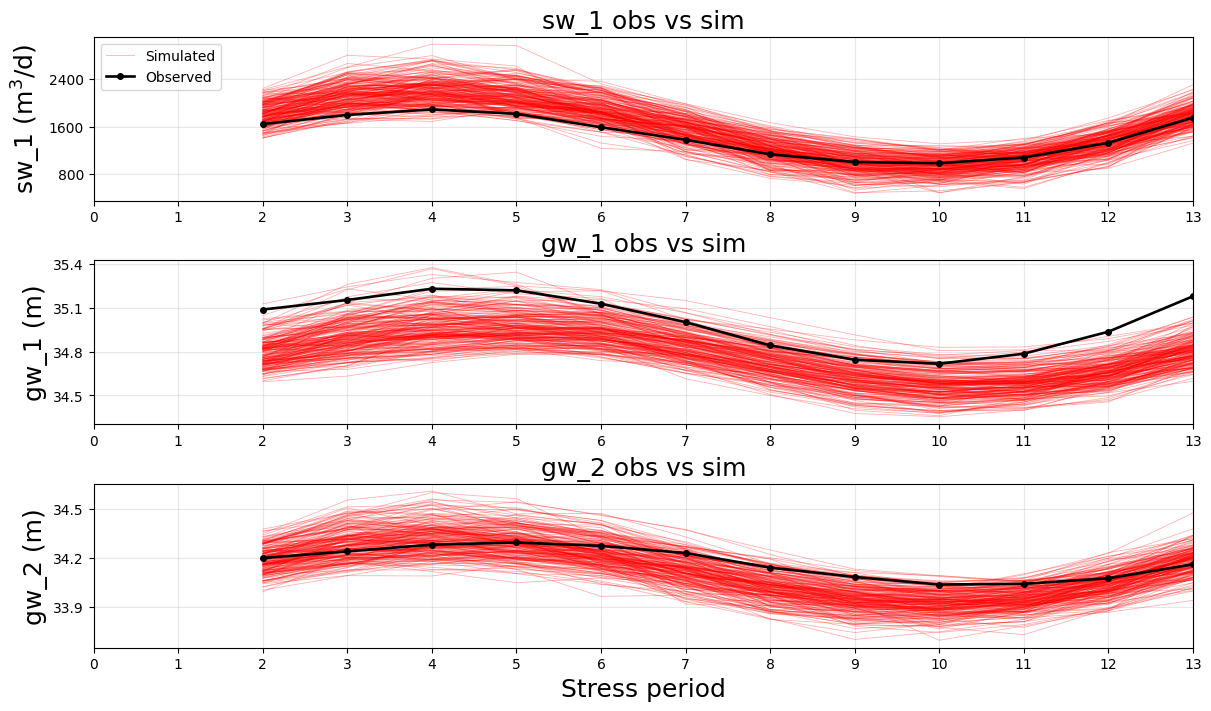

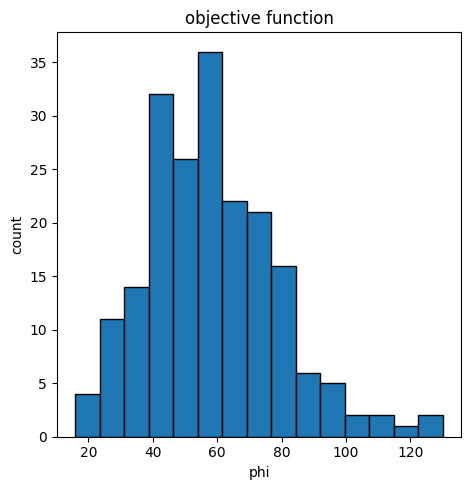

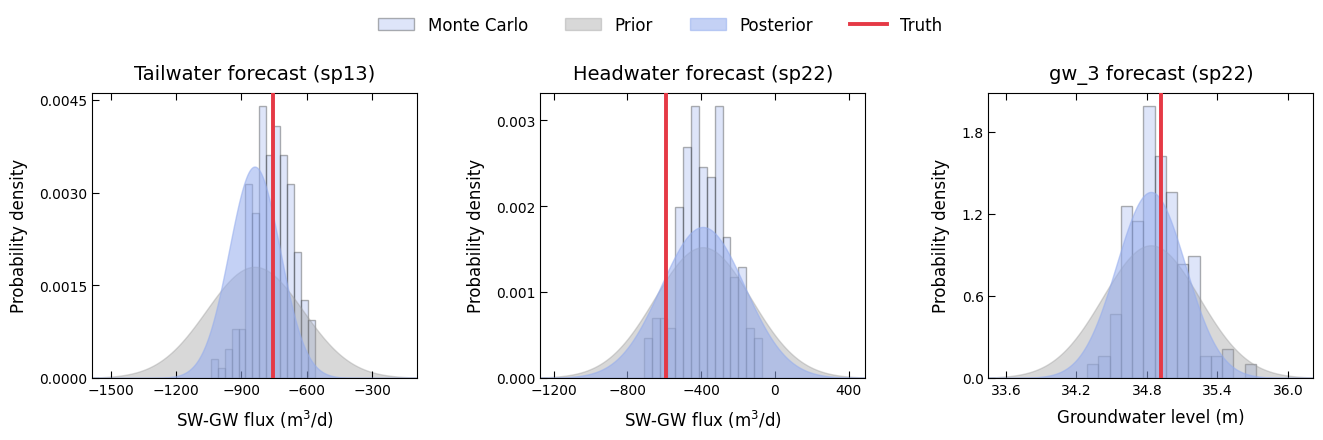

In [7]:
fs = forecast_table(la)
res = pst.res.set_index("name")
fs["post_mean"] = res.loc[fore_names, "modelled"]
truth_fore = load_truth_forecasts(TRUTH_FORECASTS, fore_names)

plot_ensemble_timeseries(sweep_filt, pst, HISTORY_SP)
plt.show()

plot_objective_hist(sweep_filt, phi_col=phi_col)
plt.show()

plot_forecast_distributions(fs, truth_fore, fore_names, sweep_filt=sweep_filt)
plt.show()

- one filtered realization's parameter fields

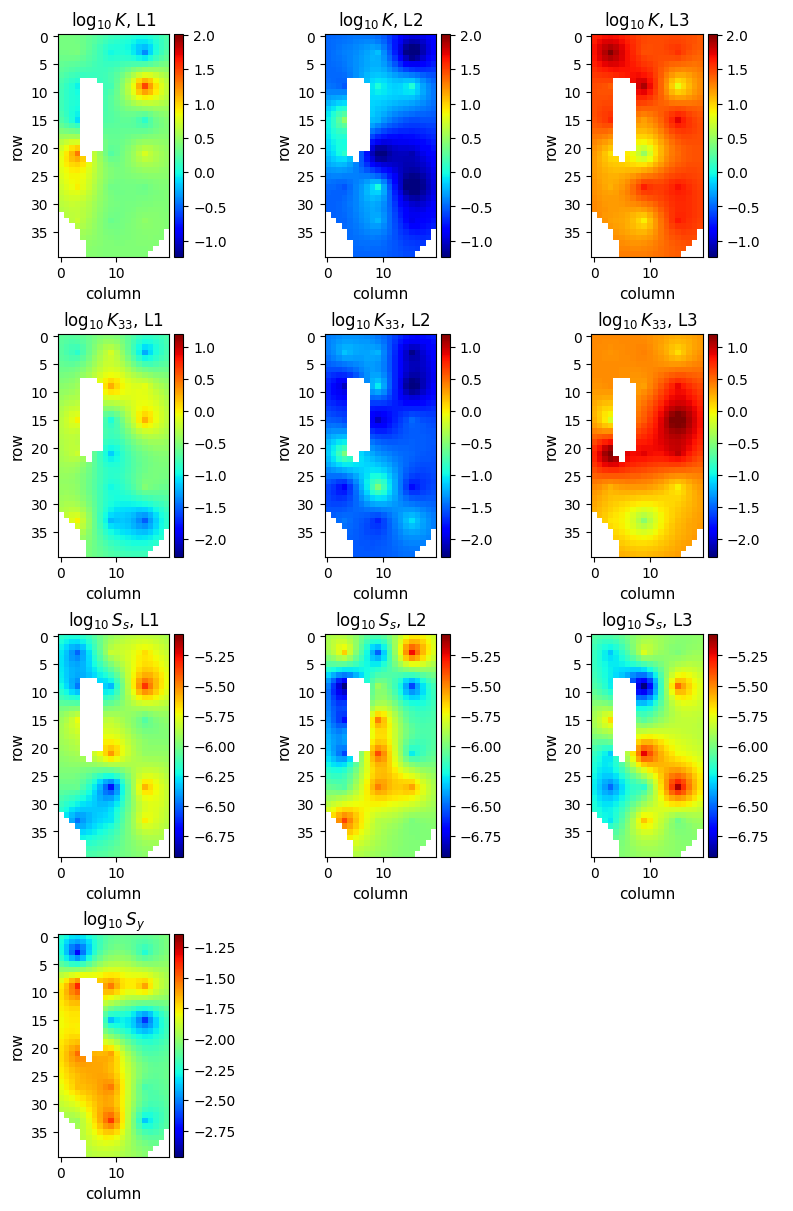

In [ ]:
# lowest-phi posterior realization field
best_id = sweep_filt.index[0]     # lowest-phi realization
par_series = sweep_in.loc[best_id]

fields = reconstruct_fields(
    pst,
    par_series,
    str(MASTER),
    PROPS,
    shape=(40, 20),
    rch_base=RCH_BASE,
    wel_base=WEL_BASE,
    nper=NPER,
)

idomain = (
    flopy.mf6.MFSimulation.load(
        sim_ws=str(MASTER),
        verbosity_level=0,
    )
    .get_model()
    .dis.idomain.array
    .astype(int)
)

tgwf = (
    flopy.mf6.MFSimulation.load(
        sim_ws=str(FINAL_TRUTH_WS),
        verbosity_level=0,
    )
    .get_model()
)

truth_fields = {}

for k in range(3):
    truth_fields[f"hk_l{k+1}"] = tgwf.npf.k.array[k]
    truth_fields[f"vk_l{k+1}"] = tgwf.npf.k33.array[k]
    truth_fields[f"ss_l{k+1}"] = tgwf.sto.ss.array[k]

truth_fields["sy_l1"] = tgwf.sto.sy.array[0]

vmins, vmaxs = field_log_ranges(truth_fields, idomain)

plot_realization_fields(
    fields,
    idomain,
    vmins=vmins,
    vmaxs=vmaxs,
)

plt.show()

Save the filtered ensemble and forecast Monte Carlo summary

In [24]:
from paths import TABLES_DIR as TABLES; TABLES.mkdir(parents=True, exist_ok=True)
sweep_filt.to_csv(TABLES / "filtered_posterior_ensemble.csv")
mc = pd.DataFrame({"truth": truth_fore})
for nm in fore_names:
    v = sweep_filt[nm.lower()].astype(float)
    mc.loc[nm, "mc_mean"] = v.mean(); mc.loc[nm, "mc_p05"] = v.quantile(0.05); mc.loc[nm, "mc_p95"] = v.quantile(0.95)
mc.to_csv(TABLES / "forecast_montecarlo.csv")
mc

,truth,mc_mean,mc_p05,mc_p95
tailwater_sp13,-754.290845,-760.553554,-924.358631,-616.873556
headwater_sp22,-590.775973,-382.755511,-620.192378,-163.057879
gw_3_sp22,34.921403,34.892392,34.530385,35.319692
